In [33]:
import copy
import logging
import numpy as np
import pandas as pd
import pyXLMS
from pyXLMS_adaptor import read
from mokapot_rescore import rescore
from post_process import group_by_residue_pair  # noqa: F401
import matplotlib.pyplot as plt

from typing import Optional
from typing import List
from typing import Dict
from typing import Tuple
from typing import Any

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

DTYPE_CSM = "crosslink-spectrum-matches"

In [2]:
from IPython.core.magic import register_cell_magic


@register_cell_magic
def skip(line, cell):
    return

In [3]:
%%skip

df = pd.read_csv(
    "../data/THIDDIAXL003_Cas9_PhoX_DIA12_CeleEntrap_100per_LibSizeTest_SN20c4_Report_FM_crosslinking_plusDecoy (Normal).tsv_annotated.csv.xz",
    compression="xz",
    low_memory=False,
)

In [4]:
%%skip

df = group_by_residue_pair(df)
df.to_csv("../data/entrapment_grouped.csv", index=False)

In [41]:
df = pd.read_csv("../data/entrapment_grouped.csv", low_memory=False)

In [42]:
rep1, rep2, rep3 = tuple(sorted(df["R.FileName"].value_counts().index.tolist()))
print(f"{rep1}\n{rep2}\n{rep3}")

20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAXL003_Cas9_PhoX_DIA12_CV486075_250ng_FAIMS_001
20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAXL003_Cas9_PhoX_DIA12_CV486075_250ng_FAIMS_002
20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAXL003_Cas9_PhoX_DIA12_CV486075_250ng_FAIMS_003


In [43]:
df_rep1 = df[df["R.FileName"] == rep1].copy()
df_rep2 = df[df["R.FileName"] == rep2].copy()
df_rep3 = df[df["R.FileName"] == rep3].copy()

In [44]:
print(f"Number of CSMs with missing organism label: {sum(df['PG.Organisms'].isna())}")

Number of CSMs with missing organism label: 1


In [45]:
df["PG.Organisms"].value_counts()

PG.Organisms
S pyogenes    14492
Celegans       3395
Name: count, dtype: int64

In [46]:
spyo = df[df["PG.Organisms"] == "S pyogenes"]
cele = df[df["PG.Organisms"] == "Celegans"]

In [47]:
csms = read(df, "EG.Cscore")[DTYPE_CSM]
csms_rep1 = read(df_rep1, "EG.Cscore")[DTYPE_CSM]
csms_rep2 = read(df_rep2, "EG.Cscore")[DTYPE_CSM]
csms_rep3 = read(df_rep3, "EG.Cscore")[DTYPE_CSM]
spyo_csms = read(spyo, "EG.Cscore")[DTYPE_CSM]
cele_csms = read(cele, "EG.Cscore")[DTYPE_CSM]

Reading CSMs...: 100%|███████████████████████████████████████████████████████████| 3395/3395 [00:01<00:00, 2715.88it/s]


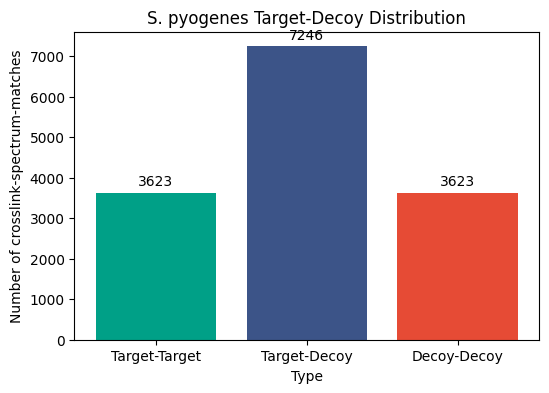

In [48]:
pyXLMS.plotting.plot_target_decoy_distribution(
    spyo_csms,
    figsize=(6, 4),
    title="S. pyogenes Target-Decoy Distribution",
    filename_prefix="plots/spyo_csms_td",
);

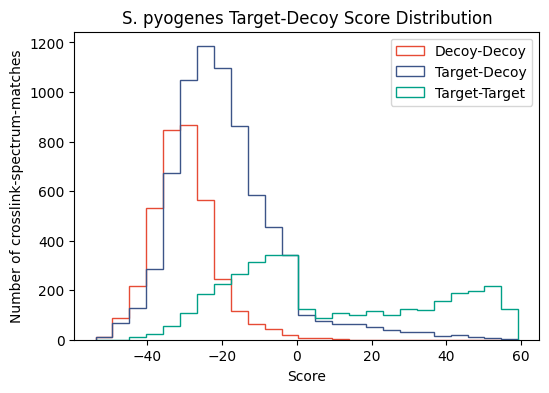

In [49]:
pyXLMS.plotting.plot_score_distribution(
    spyo_csms,
    figsize=(6, 4),
    title="S. pyogenes Target-Decoy Score Distribution",
    filename_prefix="plots/spyo_csms_td_score",
);

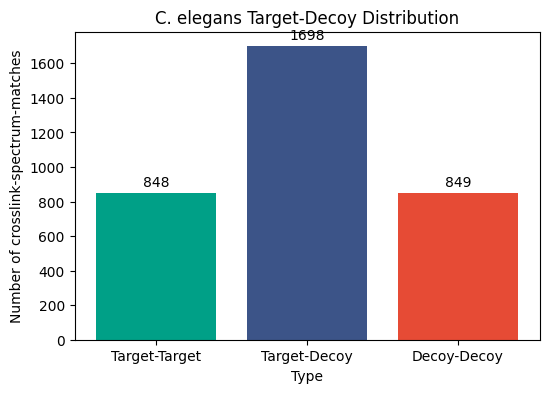

In [50]:
pyXLMS.plotting.plot_target_decoy_distribution(
    cele_csms,
    figsize=(6, 4),
    title="C. elegans Target-Decoy Distribution",
    filename_prefix="plots/cele_csms_td",
);

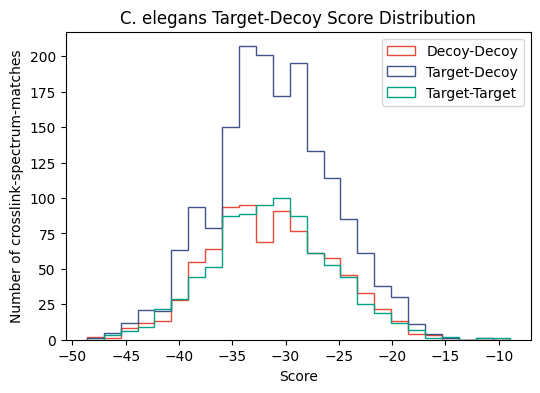

In [51]:
pyXLMS.plotting.plot_score_distribution(
    cele_csms,
    figsize=(6, 4),
    title="C. elegans Target-Decoy Score Distribution",
    filename_prefix="plots/cele_csms_td_score",
);

In [52]:
rlcsm_rep1 = rescore(df_rep1, level="CSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 5809 PSMs:
	- Target PSMs: 1390
	- Decoy PSMs: 4419
	- Unique spectra: 5809
	- Unique peptides: 5289
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverageFull', 'PP.UniScoreAlpha', 'PP.UniScoreBeta', 'PP.UniScoreFull', 'PP.PepLenAlpha', 'PP.PepLenBeta', 'PP.NumberCrosslinkFragmentsAlpha', 'PP.NumberCrosslinkFragmentsBeta', 'PP.NumberCrosslinkFragmentsFull', 'PP.Normalized

RuntimeError: No PSMs found below the 'eval_fdr' 0.01 for any feature.

In [53]:
rlcsm_rep2 = rescore(df_rep2, level="CSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 5853 PSMs:
	- Target PSMs: 1291
	- Decoy PSMs: 4562
	- Unique spectra: 5853
	- Unique peptides: 5286
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverageFull', 'PP.UniScoreAlpha', 'PP.UniScoreBeta', 'PP.UniScoreFull', 'PP.PepLenAlpha', 'PP.PepLenBeta', 'PP.NumberCrosslinkFragmentsAlpha', 'PP.NumberCrosslinkFragmentsBeta', 'PP.NumberCrosslinkFragmentsFull', 'PP.Normalized

RuntimeError: No PSMs found below the 'eval_fdr' 0.01 for any feature.

In [54]:
rlcsm_rep3 = rescore(df_rep3, level="CSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 6226 PSMs:
	- Target PSMs: 1791
	- Decoy PSMs: 4435
	- Unique spectra: 6226
	- Unique peptides: 5658
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverageFull', 'PP.UniScoreAlpha', 'PP.UniScoreBeta', 'PP.UniScoreFull', 'PP.PepLenAlpha', 'PP.PepLenBeta', 'PP.NumberCrosslinkFragmentsAlpha', 'PP.NumberCrosslinkFragmentsBeta', 'PP.NumberCrosslinkFragmentsFull', 'PP.Normalized

RuntimeError: Failed to calibrate scores between cross-validation folds, because no target PSMs could be found below 'test_fdr'. Try raising 'test_fdr'.

In [55]:
rlcsm_rep1 = rescore(df_rep1, level="CSM", use_p_and_q_values=True)

INFO:mokapot_rescore:Removed the following features because of missing values: PG.Cscore, EG.GlobalPrecursorQvalue, EG.MaxChannelQvalue, EG.MinChannelQvalue, EG.Qvalue, EG.InSourceFragmentationParentQvalue, EG.AvgProfileQvalue, EG.MaxProfileQvalue, EG.MinProfileQvalue, EG.PercentileQvalue, FG.Qvalue
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 5809 PSMs:
	- Target PSMs: 1390
	- Decoy PSMs: 4419
	- Unique spectra: 5809
	- Unique peptides: 5289
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverag

In [56]:
rlcsm_rep2 = rescore(df_rep2, level="CSM", use_p_and_q_values=True)

INFO:mokapot_rescore:Removed the following features because of missing values: PG.Cscore, EG.GlobalPrecursorQvalue, EG.MaxChannelQvalue, EG.MinChannelQvalue, EG.Qvalue, EG.InSourceFragmentationParentQvalue, EG.AvgProfileQvalue, EG.MaxProfileQvalue, EG.MinProfileQvalue, EG.PercentileQvalue, FG.Qvalue
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 5853 PSMs:
	- Target PSMs: 1291
	- Decoy PSMs: 4562
	- Unique spectra: 5853
	- Unique peptides: 5286
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverag

In [57]:
rlcsm_rep3 = rescore(df_rep3, level="CSM", use_p_and_q_values=True)

INFO:mokapot_rescore:Removed the following features because of missing values: PG.Cscore, EG.GlobalPrecursorQvalue, EG.MaxChannelQvalue, EG.MinChannelQvalue, EG.Qvalue, EG.InSourceFragmentationParentQvalue, EG.AvgProfileQvalue, EG.MaxProfileQvalue, EG.MinProfileQvalue, EG.PercentileQvalue, FG.Qvalue
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 6226 PSMs:
	- Target PSMs: 1791
	- Decoy PSMs: 4435
	- Unique spectra: 6226
	- Unique peptides: 5658
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverag

In [58]:
rlcsm_csms = dict()
rlcsm_csms["rep1"] = read(rlcsm_rep1, score="Mokapot Score")[DTYPE_CSM]
rlcsm_csms["rep2"] = read(rlcsm_rep2, score="Mokapot Score")[DTYPE_CSM]
rlcsm_csms["rep3"] = read(rlcsm_rep3, score="Mokapot Score")[DTYPE_CSM]

Reading CSMs...: 100%|███████████████████████████████████████████████████████████| 6226/6226 [00:02<00:00, 2770.30it/s]


In [59]:
rlpsm_rep1 = rescore(df_rep1, level="PSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 11618 PSMs:
	- Target PSMs: 5747
	- Decoy PSMs: 5871
	- Unique spectra: 11618
	- Unique peptides: 1460
	- Features: ('EG.Cscore', 'PP.MatchedIons', 'PP.TotalIons', 'PP.RelativeMatchScore', 'PP.PartialCscore', 'PP.SequenceCoverageNTerm', 'PP.SequenceCoverageCTerm', 'PP.SequenceCoverage', 'PP.UniScore', 'PP.PepLen', 'PP.NumberCrosslinkFragments', 'PP.NormalizedCrosslinkFragments')
INFO:mokapot.brew:Found 11618 total PSMs.
INFO:mokapot.brew:  - 5747 target PSMs and 5871 decoy PSMs detected.
INFO:mokapot.brew:Splitting PSMs into 3 folds...
INFO:mokapot.model:	- Selected feature 'PP.PartialCscore' with 334 PSMs at q<=0.01.
INFO:mokapot.model:Beginning training loop...
INFO:mokapot.model:Done tra

In [60]:
rlpsm_rep2 = rescore(df_rep2, level="PSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 11706 PSMs:
	- Target PSMs: 5563
	- Decoy PSMs: 6143
	- Unique spectra: 11706
	- Unique peptides: 1375
	- Features: ('EG.Cscore', 'PP.MatchedIons', 'PP.TotalIons', 'PP.RelativeMatchScore', 'PP.PartialCscore', 'PP.SequenceCoverageNTerm', 'PP.SequenceCoverageCTerm', 'PP.SequenceCoverage', 'PP.UniScore', 'PP.PepLen', 'PP.NumberCrosslinkFragments', 'PP.NormalizedCrosslinkFragments')
INFO:mokapot.brew:Found 11706 total PSMs.
INFO:mokapot.brew:  - 5563 target PSMs and 6143 decoy PSMs detected.
INFO:mokapot.brew:Splitting PSMs into 3 folds...
INFO:mokapot.model:	- Selected feature 'PP.PartialCscore' with 355 PSMs at q<=0.01.
INFO:mokapot.model:Beginning training loop...
INFO:mokapot.model:Done tra

In [61]:
rlpsm_rep3 = rescore(df_rep3, level="PSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 12452 PSMs:
	- Target PSMs: 6578
	- Decoy PSMs: 5874
	- Unique spectra: 12452
	- Unique peptides: 1322
	- Features: ('EG.Cscore', 'PP.MatchedIons', 'PP.TotalIons', 'PP.RelativeMatchScore', 'PP.PartialCscore', 'PP.SequenceCoverageNTerm', 'PP.SequenceCoverageCTerm', 'PP.SequenceCoverage', 'PP.UniScore', 'PP.PepLen', 'PP.NumberCrosslinkFragments', 'PP.NormalizedCrosslinkFragments')
INFO:mokapot.brew:Found 12452 total PSMs.
INFO:mokapot.brew:  - 6578 target PSMs and 5874 decoy PSMs detected.
INFO:mokapot.brew:Splitting PSMs into 3 folds...
INFO:mokapot.model:	- Selected feature 'PP.PartialCscore' with 555 PSMs at q<=0.01.
INFO:mokapot.model:Beginning training loop...
INFO:mokapot.model:Done tra

In [62]:
rlpsm_csms = dict()
rlpsm_csms["rep1"] = read(rlpsm_rep1, score="Mokapot Score")[DTYPE_CSM]
rlpsm_csms["rep2"] = read(rlpsm_rep2, score="Mokapot Score")[DTYPE_CSM]
rlpsm_csms["rep3"] = read(rlpsm_rep3, score="Mokapot Score")[DTYPE_CSM]

Reading CSMs...: 100%|███████████████████████████████████████████████████████████| 6226/6226 [00:02<00:00, 2928.56it/s]


In [63]:
def pipeline(csms, fdr: float = 0.01):
    u = pyXLMS.transform.unique(csms)
    v = pyXLMS.transform.validate(u, fdr)
    t = pyXLMS.transform.targets_only(v)
    return t

In [64]:
def get_experimental_fdr(
    csms, true_label="S pyogenes", label_col="PG.Organisms"
) -> Tuple[int, int, float]:
    nr_true = 0
    nr_false = 0
    for csm in csms:
        label = csm["additional_information"]["source"][label_col]
        if label is not None and true_label in label:
            nr_true += 1
        else:
            nr_false += 1
    return nr_true, nr_false, (nr_false / nr_true) * 100.0

### **CSM-level Rescoring**

In [65]:
rlcsm_t = dict()
rlcsm_t["rep1"] = pipeline(rlcsm_csms["rep1"])
rlcsm_t["rep2"] = pipeline(rlcsm_csms["rep2"])
rlcsm_t["rep3"] = pipeline(rlcsm_csms["rep3"])

Iterating over scores for FDR calculation...:  71%|████████████████████▋        | 4435/6226 [00:00<00:00, 64797.26it/s]


#### Replicate 1

In [70]:
rlcsm_eval1 = get_experimental_fdr(rlcsm_t["rep1"])
print(
    f"[CSM-level Rescoring]\nNumber of hits at 1% FDR: {len(rlcsm_t["rep1"])};\n"
    f"Number Target Hits: {rlcsm_eval1[0]};\n"
    f"Number Entrapment Hits: {rlcsm_eval1[1]};\n"
    f"Experimental FDR: {rlcsm_eval1[2]}%;"
)

[CSM-level Rescoring]
Number of hits at 1% FDR: 1390;
Number Target Hits: 1060;
Number Entrapment Hits: 330;
Experimental FDR: 31.132075471698112%;


#### Replicate 2

In [71]:
rlcsm_eval2 = get_experimental_fdr(rlcsm_t["rep2"])
print(
    f"[CSM-level Rescoring]\nNumber of hits at 1% FDR: {len(rlcsm_t["rep2"])};\n"
    f"Number Target Hits: {rlcsm_eval2[0]};\n"
    f"Number Entrapment Hits: {rlcsm_eval2[1]};\n"
    f"Experimental FDR: {rlcsm_eval2[2]}%;"
)

[CSM-level Rescoring]
Number of hits at 1% FDR: 1291;
Number Target Hits: 1016;
Number Entrapment Hits: 275;
Experimental FDR: 27.06692913385827%;


#### Replicate 3

In [72]:
rlcsm_eval3 = get_experimental_fdr(rlcsm_t["rep3"])
print(
    f"[CSM-level Rescoring]\nNumber of hits at 1% FDR: {len(rlcsm_t["rep3"])};\n"
    f"Number Target Hits: {rlcsm_eval3[0]};\n"
    f"Number Entrapment Hits: {rlcsm_eval3[1]};\n"
    f"Experimental FDR: {rlcsm_eval3[2]}%;"
)

[CSM-level Rescoring]
Number of hits at 1% FDR: 1791;
Number Target Hits: 1547;
Number Entrapment Hits: 244;
Experimental FDR: 15.77246283128636%;


### **PSM-level Rescoring**

In [73]:
rlpsm_t = dict()
rlpsm_t["rep1"] = pipeline(rlpsm_csms["rep1"])
rlpsm_t["rep2"] = pipeline(rlpsm_csms["rep2"])
rlpsm_t["rep3"] = pipeline(rlpsm_csms["rep3"])

Iterating over scores for FDR calculation...:  92%|█████████████████████████▋  | 5712/6226 [00:00<00:00, 108639.14it/s]


#### Replicate 1

In [76]:
rlpsm_eval1 = get_experimental_fdr(rlpsm_t["rep1"])
print(
    f"[PSM-level Rescoring]\nNumber of hits at 1% FDR: {len(rlpsm_t["rep1"])};\n"
    f"Number Target Hits: {rlpsm_eval1[0]};\n"
    f"Number Entrapment Hits: {rlpsm_eval1[1]};\n"
    f"Experimental FDR: {rlpsm_eval1[2]}%;"
)

[PSM-level Rescoring]
Number of hits at 1% FDR: 303;
Number Target Hits: 303;
Number Entrapment Hits: 0;
Experimental FDR: 0.0%;


#### Replicate 2

In [75]:
rlpsm_eval2 = get_experimental_fdr(rlpsm_t["rep2"])
print(
    f"[PSM-level Rescoring]\nNumber of hits at 1% FDR: {len(rlpsm_t["rep2"])};\n"
    f"Number Target Hits: {rlpsm_eval2[0]};\n"
    f"Number Entrapment Hits: {rlpsm_eval2[1]};\n"
    f"Experimental FDR: {rlpsm_eval2[2]}%;"
)

[PSM-level Rescoring]
Number of hits at 1% FDR: 246;
Number Target Hits: 246;
Number Entrapment Hits: 0;
Experimental FDR: 0.0%;


#### Replicate 3

In [77]:
rlpsm_eval3 = get_experimental_fdr(rlpsm_t["rep3"])
print(
    f"[PSM-level Rescoring]\nNumber of hits at 1% FDR: {len(rlpsm_t["rep3"])};\n"
    f"Number Target Hits: {rlpsm_eval3[0]};\n"
    f"Number Entrapment Hits: {rlpsm_eval3[1]};\n"
    f"Experimental FDR: {rlpsm_eval3[2]}%;"
)

[PSM-level Rescoring]
Number of hits at 1% FDR: 509;
Number Target Hits: 509;
Number Entrapment Hits: 0;
Experimental FDR: 0.0%;


### **No Rescoring**

In [78]:
rlnone_t = dict()
rlnone_t["rep1"] = pipeline(csms_rep1)
rlnone_t["rep2"] = pipeline(csms_rep2)
rlnone_t["rep3"] = pipeline(csms_rep3)

Iterating over scores for FDR calculation...:  97%|████████████████████████████▏| 6054/6226 [00:00<00:00, 92211.96it/s]


In [79]:
rlnone_eval1 = get_experimental_fdr(rlnone_t["rep1"])
print(
    f"[No Rescoring]\nNumber of hits at 1% FDR: {len(rlnone_t["rep1"])};\n"
    f"Number Target Hits: {rlnone_eval1[0]};\n"
    f"Number Entrapment Hits: {rlnone_eval1[1]};\n"
    f"Experimental FDR: {rlnone_eval1[2]}%;"
)

[No Rescoring]
Number of hits at 1% FDR: 87;
Number Target Hits: 87;
Number Entrapment Hits: 0;
Experimental FDR: 0.0%;


In [80]:
rlnone_eval2 = get_experimental_fdr(rlnone_t["rep2"])
print(
    f"[No Rescoring]\nNumber of hits at 1% FDR: {len(rlnone_t["rep2"])};\n"
    f"Number Target Hits: {rlnone_eval2[0]};\n"
    f"Number Entrapment Hits: {rlnone_eval2[1]};\n"
    f"Experimental FDR: {rlnone_eval2[2]}%;"
)

[No Rescoring]
Number of hits at 1% FDR: 30;
Number Target Hits: 30;
Number Entrapment Hits: 0;
Experimental FDR: 0.0%;


In [81]:
rlnone_eval3 = get_experimental_fdr(rlnone_t["rep3"])
print(
    f"[No Rescoring]\nNumber of hits at 1% FDR: {len(rlnone_t["rep3"])};\n"
    f"Number Target Hits: {rlnone_eval3[0]};\n"
    f"Number Entrapment Hits: {rlnone_eval3[1]};\n"
    f"Experimental FDR: {rlnone_eval3[2]}%;"
)

[No Rescoring]
Number of hits at 1% FDR: 171;
Number Target Hits: 171;
Number Entrapment Hits: 0;
Experimental FDR: 0.0%;


In [122]:
def plot_comparison_stacked(figsize, filename_prefix=None):
    method = (
        f"No Rescoring\n {np.mean([rlnone_eval1[2], rlnone_eval2[2], rlnone_eval3[2]]):.2f}% Exp. FDR",
        f"PSM-level Rescoring\n {np.mean([rlpsm_eval1[2], rlpsm_eval2[2], rlpsm_eval3[2]]):.2f}% Exp. FDR",
        f"CSM-level Rescoring\n {np.mean([rlcsm_eval1[2], rlcsm_eval2[2], rlcsm_eval3[2]]):.2f}% Exp. FDR",
    )
    counts = {
        "Target": np.array([
            np.mean([rlnone_eval1[0], rlnone_eval2[0], rlnone_eval3[0]]),
            np.mean([rlpsm_eval1[0], rlpsm_eval2[0], rlpsm_eval3[0]]),
            np.mean([rlcsm_eval1[0], rlcsm_eval2[0], rlcsm_eval3[0]]),
            ]),
        "Entrapment": np.array([
            np.mean([rlnone_eval1[1], rlnone_eval2[1], rlnone_eval3[1]]),
            np.mean([rlpsm_eval1[1], rlpsm_eval2[1], rlpsm_eval3[1]]),
            np.mean([rlcsm_eval1[1], rlcsm_eval2[1], rlcsm_eval3[1]]), 
        ]),
    }
    errors = {
        "Target": np.array([
            np.std([rlnone_eval1[0], rlnone_eval2[0], rlnone_eval3[0]]),
            np.std([rlpsm_eval1[0], rlpsm_eval2[0], rlpsm_eval3[0]]),
            np.std([rlcsm_eval1[0], rlcsm_eval2[0], rlcsm_eval3[0]]),
            ]),
        "Entrapment": np.array([
            np.std([rlnone_eval1[1], rlnone_eval2[1], rlnone_eval3[1]]),
            np.std([rlpsm_eval1[1], rlpsm_eval2[1], rlpsm_eval3[1]]),
            np.std([rlcsm_eval1[1], rlcsm_eval2[1], rlcsm_eval3[1]]), 
        ]),
    }
    colors = {
        "Target": "#00a087",
        "Entrapment": "#e64b35",
    }
    width = 0.5

    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(3)

    for label, count in counts.items():
        p = ax.bar(
            method, count, width, label=label, bottom=bottom, color=colors[label]
        )
        e = ax.errorbar(
            method, count+bottom, yerr=errors[label], fmt="o", color="black"
        )
        ax.bar_label(p, labels=[f"{c:.2f}" if c > 0 else "" for c in count], label_type="center", padding=0)
        bottom += count
    ax.set_xlabel("Rescoring Method")
    ax.set_ylabel("Number of crosslink-spectrum-matches at 1% estimated FDR")
    title = "Number of Target and Entrapment Hits per Rescoring Method"
    ax.legend(loc="upper left")

    if filename_prefix is not None:
        plt.savefig(
            filename_prefix + "_notitle.png",
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )
        plt.savefig(
            filename_prefix + "_notitle.svg",
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )
        ax.set_title(title)
        plt.savefig(
            filename_prefix + ".png", dpi=300, transparent=True, bbox_inches="tight"
        )
        plt.savefig(
            filename_prefix + ".svg", dpi=300, transparent=True, bbox_inches="tight"
        )
    else:
        ax.set_title(title)

    return (fig, ax)

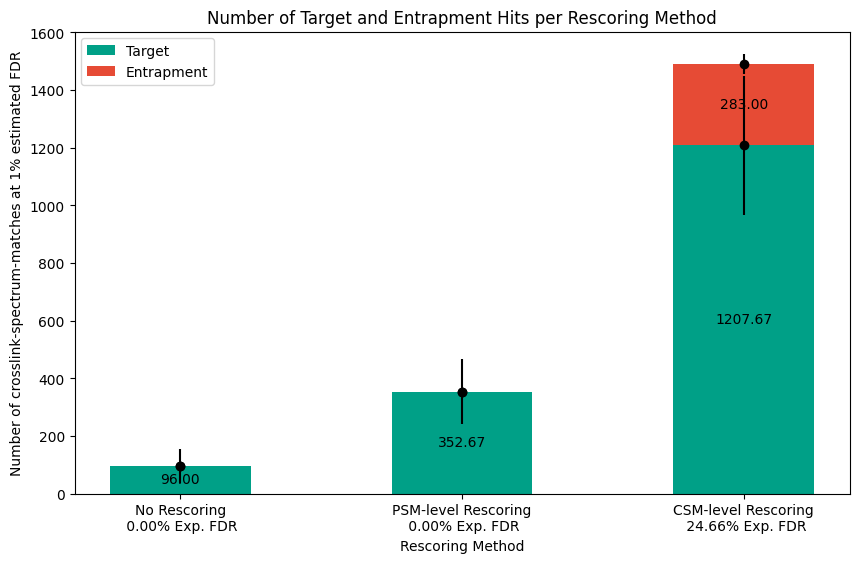

In [123]:
plot_comparison_stacked(figsize=(10, 6), filename_prefix="plots/rescoring_method_comparsion");

In [140]:
def plot_comparison_grouped(figsize, filename_prefix=None):
    method = (
        f"\nNo Rescoring\n {np.mean([rlnone_eval1[2], rlnone_eval2[2], rlnone_eval3[2]]):.2f}% Exp. FDR\n",
        f"\nPSM-level Rescoring\n {np.mean([rlpsm_eval1[2], rlpsm_eval2[2], rlpsm_eval3[2]]):.2f}% Exp. FDR\n",
        f"\nCSM-level Rescoring\n {np.mean([rlcsm_eval1[2], rlcsm_eval2[2], rlcsm_eval3[2]]):.2f}% Exp. FDR\n",
    )
    counts = {
        "Target": np.array([
            np.mean([rlnone_eval1[0], rlnone_eval2[0], rlnone_eval3[0]]),
            np.mean([rlpsm_eval1[0], rlpsm_eval2[0], rlpsm_eval3[0]]),
            np.mean([rlcsm_eval1[0], rlcsm_eval2[0], rlcsm_eval3[0]]),
            ]),
        "Entrapment": np.array([
            np.mean([rlnone_eval1[1], rlnone_eval2[1], rlnone_eval3[1]]),
            np.mean([rlpsm_eval1[1], rlpsm_eval2[1], rlpsm_eval3[1]]),
            np.mean([rlcsm_eval1[1], rlcsm_eval2[1], rlcsm_eval3[1]]), 
        ]),
    }
    errors = {
        "Target": np.array([
            np.std([rlnone_eval1[0], rlnone_eval2[0], rlnone_eval3[0]]),
            np.std([rlpsm_eval1[0], rlpsm_eval2[0], rlpsm_eval3[0]]),
            np.std([rlcsm_eval1[0], rlcsm_eval2[0], rlcsm_eval3[0]]),
            ]),
        "Entrapment": np.array([
            np.std([rlnone_eval1[1], rlnone_eval2[1], rlnone_eval3[1]]),
            np.std([rlpsm_eval1[1], rlpsm_eval2[1], rlpsm_eval3[1]]),
            np.std([rlcsm_eval1[1], rlcsm_eval2[1], rlcsm_eval3[1]]), 
        ]),
    }
    colors = {
        "Target": "#00a087",
        "Entrapment": "#e64b35",
    }
    x = np.arange(len(method))
    width = 0.4
    multiplier = 0

    fig, ax = plt.subplots(figsize=figsize)

    for label, count in counts.items():
        offset = width * multiplier
        p = ax.bar(
            x + offset, count, width, label=label, color=colors[label]
        )
        e = ax.errorbar(
            x + offset, count, yerr=errors[label], fmt="o", color="black"
        )
        ax.bar_label(p, labels=[f"{c:.0f}" for c in count], label_type="center", padding=-5)
        multiplier += 1
    ax.set_xlabel("Rescoring Method")
    ax.set_ylabel("Number of crosslink-spectrum-matches at 1% estimated FDR")
    ax.set_xticks(x + width / 2, method)
    title = "Number of Target and Entrapment Hits per Rescoring Method"
    ax.legend(loc="upper left")

    if filename_prefix is not None:
        plt.savefig(
            filename_prefix + "_notitle.png",
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )
        plt.savefig(
            filename_prefix + "_notitle.svg",
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )
        ax.set_title(title)
        plt.savefig(
            filename_prefix + ".png", dpi=300, transparent=True, bbox_inches="tight"
        )
        plt.savefig(
            filename_prefix + ".svg", dpi=300, transparent=True, bbox_inches="tight"
        )
    else:
        ax.set_title(title)

    return (fig, ax)

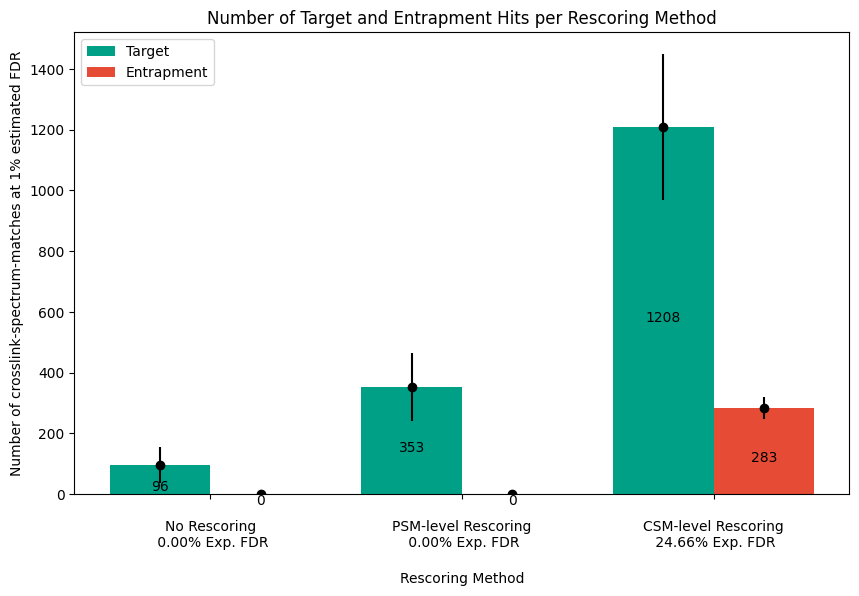

In [141]:
plot_comparison_grouped(figsize=(10, 6), filename_prefix=None);

In [120]:
rescored_level_csm_csms_spyo = list()
rescored_level_csm_csms_cele = list()
for csm in rescored_level_csm_csms:
    label = csm["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        rescored_level_csm_csms_spyo.append(csm)
    elif label is not None and "Celegans" in label:
        rescored_level_csm_csms_cele.append(csm)

NameError: name 'rescored_level_csm_csms' is not defined

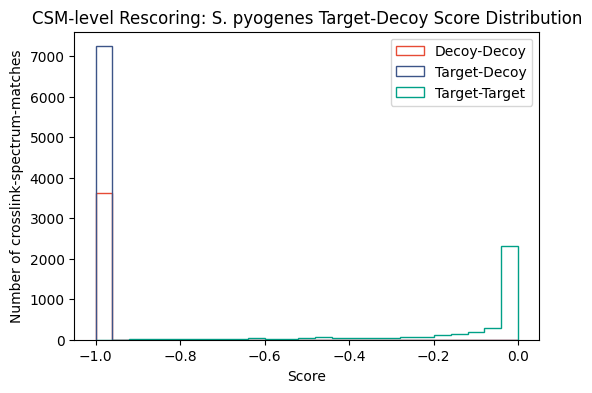

In [30]:
pyXLMS.plotting.plot_score_distribution(
    rescored_level_csm_csms_spyo,
    figsize=(6, 4),
    title="CSM-level Rescoring: S. pyogenes Target-Decoy Score Distribution",
    filename_prefix="plots/rescored_level_csm_csms_spyo_td_score",
);

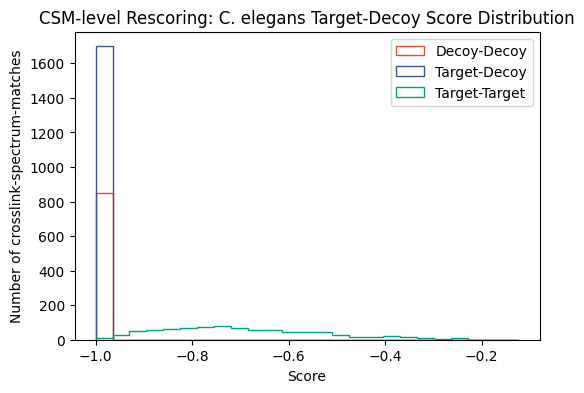

In [31]:
pyXLMS.plotting.plot_score_distribution(
    rescored_level_csm_csms_cele,
    figsize=(6, 4),
    title="CSM-level Rescoring: C. elegans Target-Decoy Score Distribution",
    filename_prefix="plots/rescored_level_csm_csms_cele_td_score",
);

In [32]:
rescored_level_psm_csms_spyo = list()
rescored_level_psm_csms_cele = list()
for csm in rescored_level_psm_csms:
    label = csm["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        rescored_level_psm_csms_spyo.append(csm)
    elif label is not None and "Celegans" in label:
        rescored_level_psm_csms_cele.append(csm)

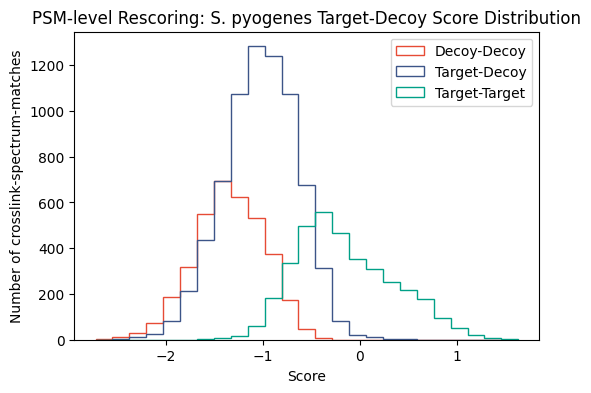

In [33]:
pyXLMS.plotting.plot_score_distribution(
    rescored_level_psm_csms_spyo,
    figsize=(6, 4),
    title="PSM-level Rescoring: S. pyogenes Target-Decoy Score Distribution",
    filename_prefix="plots/rescored_level_psm_csms_spyo_td_score",
);

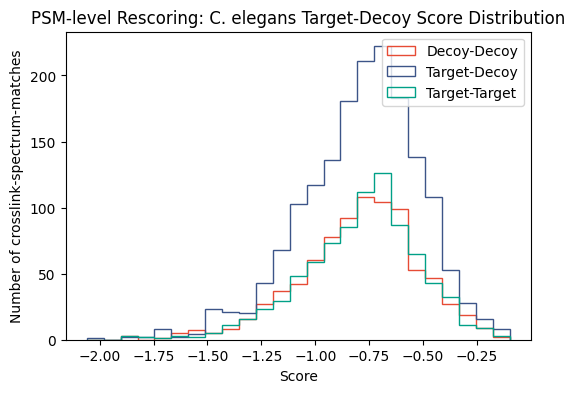

In [34]:
pyXLMS.plotting.plot_score_distribution(
    rescored_level_psm_csms_cele,
    figsize=(6, 4),
    title="PSM-level Rescoring: C. elegans Target-Decoy Score Distribution",
    filename_prefix="plots/rescored_level_psm_csms_cele_td_score",
);

In [35]:
def plot_score_distribution(
    data: List[Dict[str, Any]],
    bins: int = 25,
    density: bool = False,
    colors: List[str] = ["#00a087", "#e64b35"],
    title: str = "Target and Decoy Score Distribution",
    figsize: Tuple[float, float] = (16.0, 9.0),
    filename_prefix: Optional[str] = None,
) -> Tuple[plt.Figure, Any]:
    ylabel = (
        "crosslink-spectrum-matches"
        if data[0]["data_type"] == "crosslink-spectrum-match"
        else "crosslinks"
    )
    filtered = pyXLMS.transform.filter_target_decoy(data)
    tt = [item["score"] for item in filtered["Target-Target"]]
    _td = [item["score"] for item in filtered["Target-Decoy"]]
    dd = [item["score"] for item in filtered["Decoy-Decoy"]]

    fig, ax = plt.subplots(figsize=figsize)

    ax.hist(
        [tt, dd],
        bins=bins,
        density=density,
        histtype="step",
        fill=False,
        color=colors,
        label=["Target", "Entrapment"],
    )
    ax.legend(loc="upper right")
    ax.set_ylabel(f"Number of {ylabel}")
    ax.set_xlabel("Score")

    if filename_prefix is not None:
        plt.savefig(
            filename_prefix + "_notitle.png",
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )
        plt.savefig(
            filename_prefix + "_notitle.svg",
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )
        ax.set_title(title)
        plt.savefig(
            filename_prefix + ".png", dpi=300, transparent=True, bbox_inches="tight"
        )
        plt.savefig(
            filename_prefix + ".svg", dpi=300, transparent=True, bbox_inches="tight"
        )
    else:
        ax.set_title(title)

    return (fig, ax)

In [36]:
rescored_level_csm_csms_t = pyXLMS.transform.targets_only(rescored_level_csm_csms)
rescored_level_csm_csms_t = copy.deepcopy(rescored_level_csm_csms_t)
for csm in rescored_level_csm_csms_t:
    label = csm["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        csm["alpha_decoy"] = False
        csm["beta_decoy"] = False
    elif label is not None and "Celegans" in label:
        csm["alpha_decoy"] = True
        csm["beta_decoy"] = True

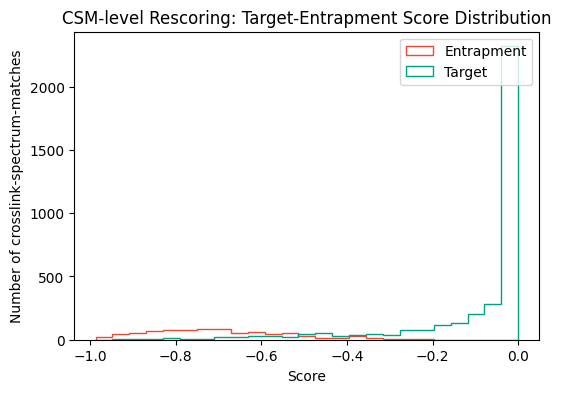

In [37]:
plot_score_distribution(
    rescored_level_csm_csms_t,
    figsize=(6, 4),
    title="CSM-level Rescoring: Target-Entrapment Score Distribution",
    filename_prefix="plots/rescored_level_csm_csms_te_score",
);

In [38]:
rescored_level_psm_csms_t = pyXLMS.transform.targets_only(rescored_level_psm_csms)
rescored_level_psm_csms_t = copy.deepcopy(rescored_level_psm_csms_t)
for csm in rescored_level_psm_csms_t:
    label = csm["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        csm["alpha_decoy"] = False
        csm["beta_decoy"] = False
    elif label is not None and "Celegans" in label:
        csm["alpha_decoy"] = True
        csm["beta_decoy"] = True

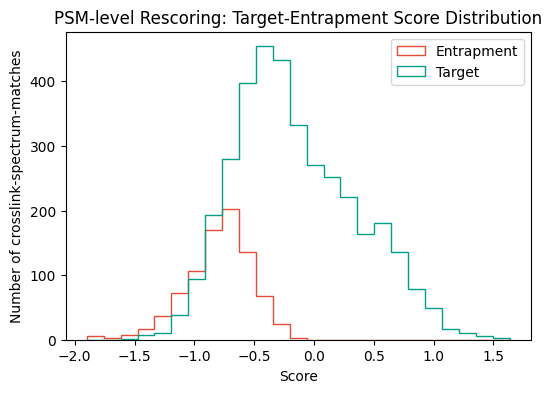

In [39]:
plot_score_distribution(
    rescored_level_psm_csms_t,
    figsize=(6, 4),
    title="PSM-level Rescoring: Target-Entrapment Score Distribution",
    filename_prefix="plots/rescored_level_psm_csms_te_score",
);